# Expresso Churn Prediction — Complete Pipeline

Solo, Kaggle-ready notebook for the [Expresso churn prediction](https://zindi.world/competitions/expresso-churn-prediction)
challenge. It merges the exploratory work from `StarterNotebook_Soumedhik.ipynb`
(missingness analysis, duplicate/label-noise analysis) with the base
`StarterNotebook.ipynb` template into one clean, end-to-end pipeline.

**How this notebook is organized**

1. Problem statement & data dictionary
2. Load data (auto-detects the Kaggle input path)
3. First look at the data
4. Data cleaning & preprocessing
5. Exploratory visualization
6. Train/validation split & preprocessing pipeline
7. Baseline model — Logistic Regression
8. Hypotheses (informed by the EDA + baseline)
9. Training additional models
10. Model comparison
11. Visualizing the best model
12. Results, discussion & conclusions
13. Kaggle submission

> **Run this on Kaggle.** Attach the competition dataset to the notebook (Add
> Data → search "Expresso Churn Prediction" / upload `Train.csv`, `Test.csv`,
> `SampleSubmission.csv`). The data-loading cell below searches `/kaggle/input`
> automatically, so no path needs to be hard-coded. This notebook has **not**
> been executed locally — run it top to bottom on Kaggle.

## 0. Problem Statement

*(Taken from the [Zindi competition page](https://zindi.world/competitions/expresso-churn-prediction))*

Expresso is an African telecommunications company that provides customers with
airtime and mobile data bundles. The objective is to build a machine learning
model that predicts the likelihood of each Expresso customer **churning**,
i.e. becoming inactive and making no transactions for 90 days.

### Data dictionary

| Variable | Description | Data type |
|---|---|---|
| `user_id` | Unique customer identifier | object |
| `REGION` | Client location | object |
| `TENURE` | Duration in the network | object (ordinal) |
| `MONTANT` | Top-up amount | float64 |
| `FREQUENCE_RECH` | Number of times the customer refilled | float64 |
| `REVENUE` | Monthly revenue generated by the client | float64 |
| `ARPU_SEGMENT` | Revenue over 90 days / 3 | float64 |
| `FREQUENCE` | Number of times the client generated revenue | float64 |
| `DATA_VOLUME` | Number of connections | float64 |
| `ON_NET` | Calls within Expresso | float64 |
| `ORANGE` | Calls to Orange | float64 |
| `TIGO` | Calls to Tigo | float64 |
| `ZONE1` | Calls to zone 1 | float64 |
| `ZONE2` | Calls to zone 2 | float64 |
| `MRG` | Undocumented; verified constant column | object |
| `REGULARITY` | Number of times the client is active over 90 days | int64 |
| `TOP_PACK` | Client's most frequently activated pack | object |
| `FREQ_TOP_PACK` | Number of times the client activated the top pack | float64 |
| `CHURN` | **Target** — 1 if the customer churned | int64 |

We will re-derive most of these facts (dtypes, missingness, cardinality)
directly from the data rather than hard-coding them, so this section is a
reference, not a source of truth.

## 1. Setup

In [1]:
import glob
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_style("darkgrid")
rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 60)
%matplotlib inline

RANDOM_STATE = 42

In [2]:
# If you want a quick smoke-test of the whole pipeline before committing to the
# full ~2.15M-row training set, lower this fraction (e.g. 0.1 for a ~10x faster
# dry run). Set it back to 1.0 for the real run / final Kaggle submission.
SAMPLE_FRAC = 1.0

## 2. Load Data

`locate_file` searches `/kaggle/input/**` first (so this works unmodified on
Kaggle regardless of the exact dataset slug), then falls back to a local
`Data/` folder for local experimentation.

In [3]:
def locate_file(filename: str) -> str:
    """Find a data file whether we're running on Kaggle or locally."""
    kaggle_matches = glob.glob(f"/kaggle/input/**/{filename}", recursive=True)
    if kaggle_matches:
        return kaggle_matches[0]
    for local_dir in ("Data", os.path.join("..", "Data")):
        local_path = os.path.join(local_dir, filename)
        if os.path.exists(local_path):
            return local_path
    raise FileNotFoundError(
        f"Could not find {filename!r}. On Kaggle, attach the Expresso churn "
        "dataset to this notebook (Add Data); locally, place Train.csv / "
        "Test.csv / SampleSubmission.csv under a 'Data' folder."
    )


train_path = locate_file("Train.csv")
test_path = locate_file("Test.csv")
submission_path = locate_file("SampleSubmission.csv")

print(f"Train:      {train_path}")
print(f"Test:       {test_path}")
print(f"Submission: {submission_path}")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
submission = pd.read_csv(submission_path)

if SAMPLE_FRAC < 1.0:
    train = train.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"Subsampled training data to {len(train):,} rows (SAMPLE_FRAC={SAMPLE_FRAC}).")

train.shape, test.shape, submission.shape

Train:      /kaggle/input/datasets/hamzaghanmi/expresso-churn-prediction-challenge/Train.csv
Test:       /kaggle/input/datasets/hamzaghanmi/expresso-churn-prediction-challenge/Test.csv
Submission: /kaggle/input/datasets/hamzaghanmi/expresso-churn-prediction-challenge/SampleSubmission.csv


((2154048, 19), (380127, 18), (380127, 2))

In [4]:
# Optional: the variable-definitions CSV isn't guaranteed to be attached on
# Kaggle (it's a reference file, not part of Train/Test), so this is best-effort.
try:
    var_def_path = locate_file("VariableDefinitions.csv")
    definitions = pd.read_csv(var_def_path, skiprows=1)
    definitions = definitions.rename(columns={"Unnamed: 0": "variable"}).drop(columns=["French"])
    definitions = definitions.dropna(subset=["variable"])
    definitions["dtype"] = definitions["variable"].map(train.dtypes.astype(str))
    display(definitions)
except FileNotFoundError:
    print("VariableDefinitions.csv not found in this environment — see the data dictionary in Section 0.")

VariableDefinitions.csv not found in this environment — see the data dictionary in Section 0.


## 3. First Look at the Data

In [5]:
train.head()

,user_id,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,MRG,REGULARITY,TOP_PACK,FREQ_TOP_PACK,CHURN
0,00000bfd7d50f01092811bc0c8d7b0d6fe7c3596,FATICK,K > 24 month,4250.0,15.0,4251.0,1417.0,17.0,4.0,388.0,46.0,1.0,1.0,2.0,NO,54,On net 200F=Unlimited _call24H,8.0,0
1,00000cb4a5d760de88fecb38e2f71b7bec52e834,NaN,I 18-21 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,4,NaN,NaN,1
2,00001654a9d9f96303d9969d0a4a851714a4bb57,NaN,K > 24 month,3600.0,2.0,1020.0,340.0,2.0,NaN,90.0,46.0,7.0,NaN,NaN,NO,17,On-net 1000F=10MilF;10d,1.0,0
3,00001dd6fa45f7ba044bd5d84937be464ce78ac2,DAKAR,K > 24 month,13500.0,15.0,13502.0,4501.0,18.0,43804.0,41.0,102.0,2.0,NaN,NaN,NO,62,"Data:1000F=5GB,7d",11.0,0
4,000028d9e13a595abe061f9b58f3d76ab907850f,DAKAR,K > 24 month,1000.0,1.0,985.0,328.0,1.0,NaN,39.0,24.0,NaN,NaN,NaN,NO,11,Mixt 250F=Unlimited_call24H,2.0,0


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2154048 entries, 0 to 2154047
Data columns (total 19 columns):
 #   Column          Dtype  
---  ------          -----  
 0   user_id         object 
 1   REGION          object 
 2   TENURE          object 
 3   MONTANT         float64
 4   FREQUENCE_RECH  float64
 5   REVENUE         float64
 6   ARPU_SEGMENT    float64
 7   FREQUENCE       float64
 8   DATA_VOLUME     float64
 9   ON_NET          float64
 10  ORANGE          float64
 11  TIGO            float64
 12  ZONE1           float64
 13  ZONE2           float64
 14  MRG             object 
 15  REGULARITY      int64  
 16  TOP_PACK        object 
 17  FREQ_TOP_PACK   float64
 18  CHURN           int64  
dtypes: float64(12), int64(2), object(5)
memory usage: 312.2+ MB


In [7]:
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"Overall churn rate (train): {train['CHURN'].mean():.4f}")

Train shape: (2154048, 19)
Test shape:  (380127, 18)
Overall churn rate (train): 0.1875


Both `train` and `test` share the same feature columns except `test` has no
`CHURN`. `test` also carries `user_id`, which we need to keep for the final
submission but must **not** feed into any model as a feature.

## 4. Data Cleaning & Preprocessing

We work through this in five steps:

1. Drop constant / non-feature columns.
2. Quantify missingness, and check whether it's informative (spoiler: it is).
3. Quantify duplicate feature rows with conflicting labels — this sets a
   realistic ceiling on how well *any* model can do.
4. Fill missing values in a way that preserves the "missingness is
   informative" signal, instead of silently discarding it.
5. Tame the high-cardinality `TOP_PACK` and encode ordinal `TENURE`.

### 4.1 Constant / non-feature columns

In [8]:
for col in train.columns:
    n_unique = train[col].nunique(dropna=False)
    if n_unique <= 1:
        print(f"Constant column detected: {col!r} ({n_unique} unique value) -> drop")

Constant column detected: 'MRG' (1 unique value) -> drop


`MRG` is constant across the whole dataset, so it carries zero information —
we drop it. `user_id` is a unique identifier, not a feature; we keep it around
only to build the final submission file.

### 4.2 Missing values — how much, and does missingness carry meaning?

In [9]:
missing_counts = train.isna().sum()
missing_pct = (missing_counts / len(train) * 100).round(2)
missing_summary = (
    pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
    .loc[missing_counts > 0]
    .sort_values("missing_pct", ascending=False)
)
missing_summary

,missing_count,missing_pct
ZONE2,2017224,93.65
ZONE1,1984327,92.12
TIGO,1290016,59.89
DATA_VOLUME,1060433,49.23
FREQ_TOP_PACK,902594,41.90
TOP_PACK,902594,41.90
ORANGE,895248,41.56
REGION,849299,39.43
ON_NET,786675,36.52
MONTANT,756739,35.13


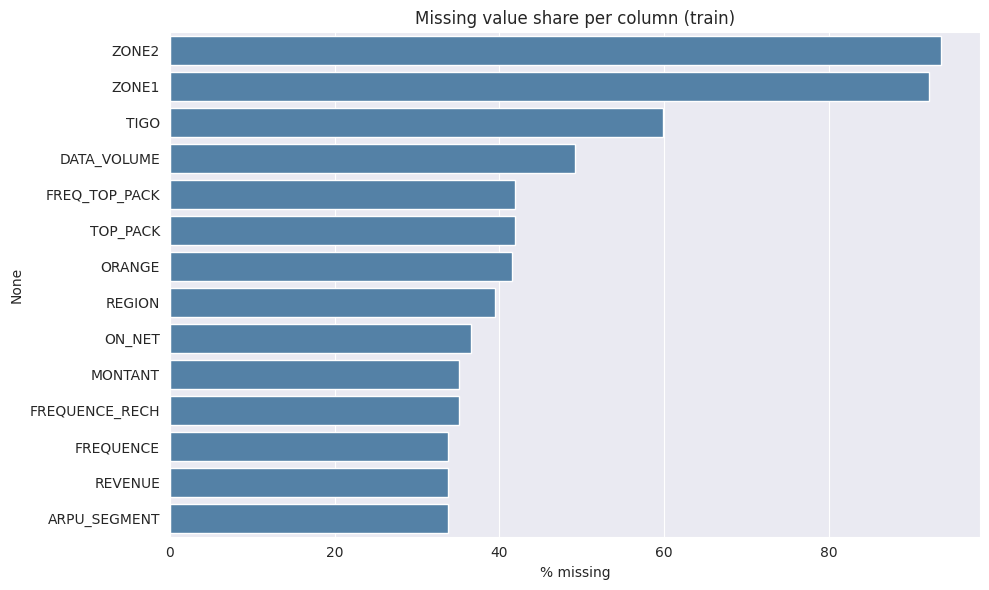

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_summary["missing_pct"], y=missing_summary.index, color="steelblue")
plt.xlabel("% missing")
plt.title("Missing value share per column (train)")
plt.tight_layout()
plt.show()

In [11]:
def churn_rate_by_missingness(df, col, target="CHURN"):
    is_missing = df[col].isna()
    return (
        pd.DataFrame({f"{col}_missing": is_missing, target: df[target]})
        .groupby(f"{col}_missing")[target]
        .agg(customers="size", churn_rate="mean")
    )

cols_with_na = missing_summary.index.tolist()

missingness_vs_churn = pd.concat(
    {col: churn_rate_by_missingness(train, col) for col in cols_with_na},
    names=["column", "is_missing"],
)
missingness_vs_churn

customers  churn_rate
column         is_missing                       
ZONE2          False          136824    0.053434
               True          2017224    0.196644
ZONE1          False          169721    0.044809
               True          1984327    0.199756
TIGO           False          864032    0.030779
               True          1290016    0.292548
DATA_VOLUME    False         1093615    0.073024
               True          1060433    0.305654
FREQ_TOP_PACK  False         1251454    0.040161
               True           902594    0.391899
TOP_PACK       False         1251454    0.040161
               True           902594    0.391899
ORANGE         False         1258800    0.040450
               True           895248    0.394380
REGION         False         1304749    0.018020
               True           849299    0.447987
ON_NET         False         1367373    0.052004
               True           786675    0.423144
MONTANT        False         1397309    0.050035
               True           756739    0.441463
FREQUENCE_RECH False         1397309    0.050035
               True           756739    0.441463
FREQUENCE      False         1428000    0.054057
               True           726048    0.450098
REVENUE        False         1428000    0.054057
               True           726048    0.450098
ARPU_SEGMENT   False         1428000    0.054057
               True           726048    0.450098

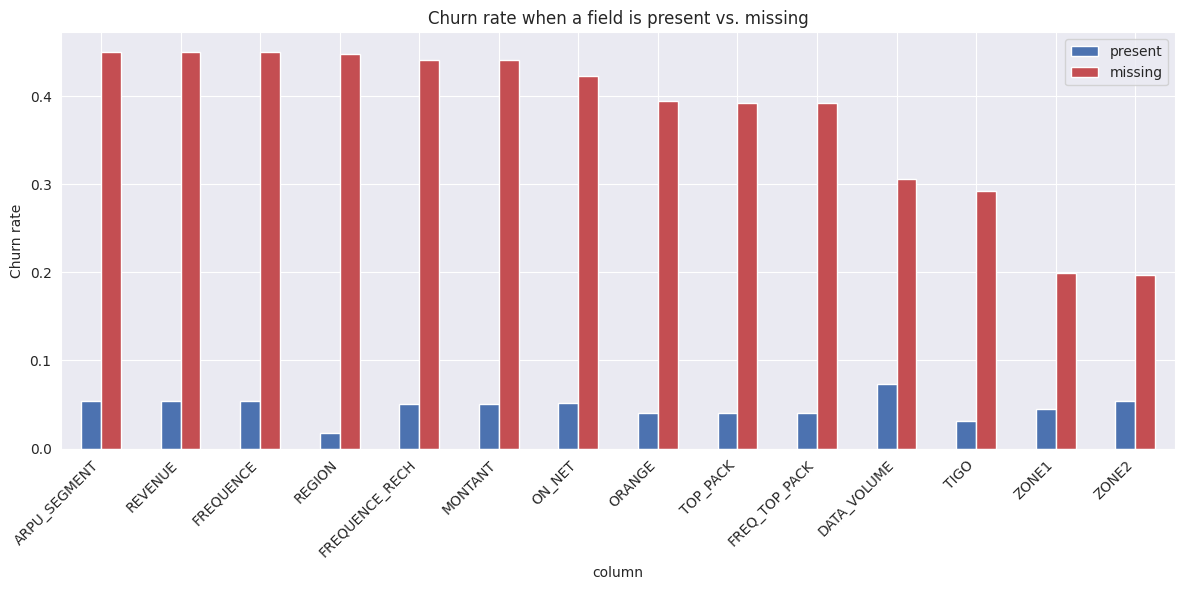

In [12]:
plot_df = missingness_vs_churn["churn_rate"].unstack("is_missing")
plot_df.columns = ["present", "missing"]
plot_df = plot_df.sort_values("missing", ascending=False)

plot_df.plot(kind="bar", figsize=(12, 6), color=["#4C72B0", "#C44E52"])
plt.ylabel("Churn rate")
plt.title("Churn rate when a field is present vs. missing")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Key finding:** for every column with missing values, the churn rate among
customers with a missing value is dramatically higher (roughly 40–45%) than
among customers with the value present (roughly 2–7%). This is not what we'd
expect if values were Missing Completely At Random — it strongly suggests
`NaN` means "this customer never used/topped-up this service in the period",
which is itself a churn signal (an inactive customer looks a lot like a
customer who is about to churn).

This shapes a concrete modeling decision: **don't drop `REGION` / `TOP_PACK`
because they have gaps, and don't only mean-impute the numeric columns** (as
the original starter code did) — instead, keep an explicit `_WAS_MISSING`
indicator per column so the signal survives imputation. We build that in 4.4.

### 4.3 Duplicate feature rows & a realistic label-noise ceiling

In [13]:
feature_cols = [c for c in train.columns if c not in ("user_id", "CHURN", "MRG")]
dup_mask = train.duplicated(subset=feature_cols, keep=False)

print(f"Rows sharing an identical feature signature with >=1 other row: {dup_mask.sum():,} ({dup_mask.mean():.1%})")

dup_groups = (
    train.loc[dup_mask]
    .groupby(feature_cols, dropna=False, observed=True, sort=False)["CHURN"]
    .agg(rows="size", churn_1="sum", distinct_labels="nunique")
)
dup_groups["churn_0"] = dup_groups["rows"] - dup_groups["churn_1"]
conflicting = dup_groups.loc[dup_groups["distinct_labels"] > 1].sort_values("rows", ascending=False)

print(f"Feature-identical groups:            {len(dup_groups):,}")
print(f"Groups with conflicting CHURN labels: {len(conflicting):,}")
print(f"Rows inside conflicting groups:       {conflicting['rows'].sum():,} ({conflicting['rows'].sum() / len(train):.1%} of train)")

# Noise ceiling: a model that only sees these features cannot beat a "predict
# the majority label per group" oracle on rows that share an identical
# feature signature but disagree on the label.
majority_correct = np.maximum(conflicting["churn_0"], conflicting["churn_1"]).sum()
oracle_accuracy_on_conflicting = majority_correct / conflicting["rows"].sum()
print(f"Best possible accuracy on conflicting groups (majority vote): {oracle_accuracy_on_conflicting:.3f}")

conflicting.head(10).reset_index()

Rows sharing an identical feature signature with >=1 other row: 674,951 (31.3%)
Feature-identical groups:            22,075
Groups with conflicting CHURN labels: 8,769
Rows inside conflicting groups:       613,671 (28.5% of train)
Best possible accuracy on conflicting groups (majority vote): 0.709


,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,TOP_PACK,FREQ_TOP_PACK,rows,churn_1,distinct_labels,churn_0
0,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,129858,102523,2,27335
1,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,69104,48062,2,21042
2,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,42970,26649,2,16321
3,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,29491,16901,2,12590
4,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN,21349,11124,2,10225
5,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN,NaN,16174,7760,2,8414
6,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN,NaN,12609,5620,2,6989
7,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,NaN,NaN,9798,4155,2,5643
8,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,NaN,7770,3086,2,4684
9,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,6510,2408,2,4102


A meaningful share of customers share an *identical* feature signature with at
least one other customer who received the **opposite** churn label. That
means our 17 features do not fully determine churn — some of it depends on
information we don't have. No classifier, however good, can reach 100%
accuracy on this feature set; the "majority vote per group" number above is a
practical ceiling to keep in mind when we look at model scores later, so we
don't chase an unrealistic target.

### 4.4 Handling missing values (indicators + fill, not mean-imputation)

In [14]:
NUMERIC_COLS = [
    "MONTANT", "FREQUENCE_RECH", "REVENUE", "ARPU_SEGMENT", "FREQUENCE",
    "DATA_VOLUME", "ON_NET", "ORANGE", "TIGO", "ZONE1", "ZONE2",
    "REGULARITY", "FREQ_TOP_PACK",
]
CATEGORICAL_COLS = ["REGION", "TOP_PACK"]

# Only the numeric columns lose information when filled with a constant (0),
# since 0 is itself a valid measured value. The categorical columns get an
# explicit "Unknown" category instead, which already preserves the signal in
# one-hot form, so we don't need a separate indicator for them.
NUMERIC_COLS_WITH_NA = [c for c in NUMERIC_COLS if c in cols_with_na]
MISSING_IND_COLS = [f"{c}_WAS_MISSING" for c in NUMERIC_COLS_WITH_NA]


def engineer_missing_indicators(df):
    df = df.copy()
    for col in NUMERIC_COLS_WITH_NA:
        df[f"{col}_WAS_MISSING"] = df[col].isna().astype(int)
    return df


train = engineer_missing_indicators(train)
test = engineer_missing_indicators(test)

train[MISSING_IND_COLS].mean().sort_values(ascending=False)

ZONE2_WAS_MISSING             0.936481
ZONE1_WAS_MISSING             0.921208
TIGO_WAS_MISSING              0.598880
DATA_VOLUME_WAS_MISSING       0.492298
FREQ_TOP_PACK_WAS_MISSING     0.419022
ORANGE_WAS_MISSING            0.415612
ON_NET_WAS_MISSING            0.365208
MONTANT_WAS_MISSING           0.351310
FREQUENCE_RECH_WAS_MISSING    0.351310
REVENUE_WAS_MISSING           0.337062
ARPU_SEGMENT_WAS_MISSING      0.337062
FREQUENCE_WAS_MISSING         0.337062
dtype: float64

In [15]:
for df in (train, test):
    df[NUMERIC_COLS] = df[NUMERIC_COLS].fillna(0)
    df[CATEGORICAL_COLS] = df[CATEGORICAL_COLS].fillna("Unknown")

train[NUMERIC_COLS + CATEGORICAL_COLS].isna().sum().sum()  # should be 0

np.int64(0)

### 4.5 Taming `TOP_PACK` cardinality

In [16]:
train["TOP_PACK"].value_counts().head(10)

TOP_PACK
Unknown                                      902594
All-net 500F=2000F;5d                        317802
On net 200F=Unlimited _call24H               152295
Data:490F=1GB,7d                             115180
Data: 100 F=40MB,24H                          84649
Mixt 250F=Unlimited_call24H                   67512
MIXT:500F= 2500F on net _2500F off net;2d     64412
Data:1000F=2GB,30d                            59770
All-net 500F =2000F_AllNet_Unlimited          46890
Jokko_Daily                                   45036
Name: count, dtype: int64

`TOP_PACK` has well over a hundred distinct values, most seen only a handful
of times — one-hot encoding all of them would blow up the feature space with
almost no benefit. We keep the most frequent packs (computed on **train
only**, to avoid leaking test-set frequency information) and bucket everything
else — including the "Unknown" placeholder we just created for missing values
— into a single category.

In [17]:
TOP_PACK_KEEP = 15
top_pack_frequent = train["TOP_PACK"].value_counts().head(TOP_PACK_KEEP).index.tolist()


def bucket_top_pack(df):
    df = df.copy()
    df["TOP_PACK_BUCKET"] = np.where(df["TOP_PACK"].isin(top_pack_frequent), df["TOP_PACK"], "Other")
    return df


train = bucket_top_pack(train)
test = bucket_top_pack(test)

train["TOP_PACK_BUCKET"].value_counts()

TOP_PACK_BUCKET
Unknown                                      902594
All-net 500F=2000F;5d                        317802
Other                                        155301
On net 200F=Unlimited _call24H               152295
Data:490F=1GB,7d                             115180
Data: 100 F=40MB,24H                          84649
Mixt 250F=Unlimited_call24H                   67512
MIXT:500F= 2500F on net _2500F off net;2d     64412
Data:1000F=2GB,30d                            59770
All-net 500F =2000F_AllNet_Unlimited          46890
Jokko_Daily                                   45036
Data: 200 F=100MB,24H                         42841
IVR Echat_Daily_50F                           28658
On-net 500=4000,10d                           26733
On-net 500F_FNF;3d                            22332
Data:200F=Unlimited,24H                       22043
Name: count, dtype: int64

Note that `Unknown` (i.e. missing) ends up among the largest buckets — that's
expected and consistent with the missingness finding in 4.2, not a bug.

### 4.6 Encoding ordinal `TENURE`

In [18]:
train["TENURE"].value_counts()

TENURE
K > 24 month     2043201
I 18-21 month      45278
H 15-18 month      26006
G 12-15 month      14901
J 21-24 month      12725
F 9-12 month        9328
E 6-9 month         1839
D 3-6 month          770
Name: count, dtype: int64

In [19]:
# TENURE has a natural order (time spent in the network); encode it as an
# ordinal integer instead of one-hot, so models can exploit the ordering.
TENURE_ORDER = [
    "D 3-6 month", "E 6-9 month", "F 9-12 month", "G 12-15 month",
    "H 15-18 month", "I 18-21 month", "J 21-24 month", "K > 24 month",
]
tenure_map = {cat: i for i, cat in enumerate(TENURE_ORDER)}

train["TENURE_ORD"] = train["TENURE"].map(tenure_map).fillna(-1)
test["TENURE_ORD"] = test["TENURE"].map(tenure_map).fillna(-1)

train[["TENURE", "TENURE_ORD"]].drop_duplicates().sort_values("TENURE_ORD")

,TENURE,TENURE_ORD
695,D 3-6 month,0
950,E 6-9 month,1
175,F 9-12 month,2
12,G 12-15 month,3
17,H 15-18 month,4
1,I 18-21 month,5
116,J 21-24 month,6
0,K > 24 month,7


In [20]:
NUMERIC_FEATURES = NUMERIC_COLS + MISSING_IND_COLS + ["TENURE_ORD"]
CATEGORICAL_FEATURES = ["REGION", "TOP_PACK_BUCKET"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "CHURN"

print(f"{len(NUMERIC_FEATURES)} numeric features, {len(CATEGORICAL_FEATURES)} categorical features")
FEATURES

26 numeric features, 2 categorical features


['MONTANT',
 'FREQUENCE_RECH',
 'REVENUE',
 'ARPU_SEGMENT',
 'FREQUENCE',
 'DATA_VOLUME',
 'ON_NET',
 'ORANGE',
 'TIGO',
 'ZONE1',
 'ZONE2',
 'REGULARITY',
 'FREQ_TOP_PACK',
 'MONTANT_WAS_MISSING',
 'FREQUENCE_RECH_WAS_MISSING',
 'REVENUE_WAS_MISSING',
 'ARPU_SEGMENT_WAS_MISSING',
 'FREQUENCE_WAS_MISSING',
 'DATA_VOLUME_WAS_MISSING',
 'ON_NET_WAS_MISSING',
 'ORANGE_WAS_MISSING',
 'TIGO_WAS_MISSING',
 'ZONE1_WAS_MISSING',
 'ZONE2_WAS_MISSING',
 'FREQ_TOP_PACK_WAS_MISSING',
 'TENURE_ORD',
 'REGION',
 'TOP_PACK_BUCKET']

## 5. Exploratory Visualization

Histograms/boxplots over 2M+ rows render slowly and add little extra insight
past a few hundred thousand points, so we draw a random sample purely for
plotting. Aggregation-based charts (value counts, group means) still run on
the **full** `train` set.

In [21]:
plot_sample = train.sample(n=min(200_000, len(train)), random_state=RANDOM_STATE)

### 5.1 Target balance

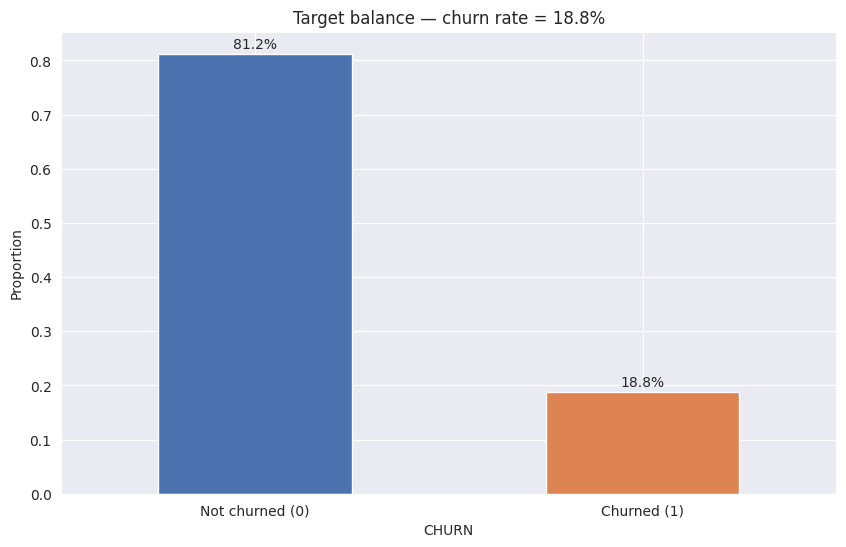

In [22]:
churn_counts = train["CHURN"].value_counts(normalize=True).sort_index()

ax = churn_counts.plot(kind="bar", color=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["Not churned (0)", "Churned (1)"], rotation=0)
ax.set_ylabel("Proportion")
ax.set_title(f"Target balance — churn rate = {train['CHURN'].mean():.1%}")
for i, v in enumerate(churn_counts):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.show()

The target is meaningfully imbalanced (roughly 4:1 stayed:churned). We'll
account for this with class weights during training and by looking at
precision/recall/F1/PR-AUC rather than accuracy alone.

### 5.2 REGION — volume and churn rate

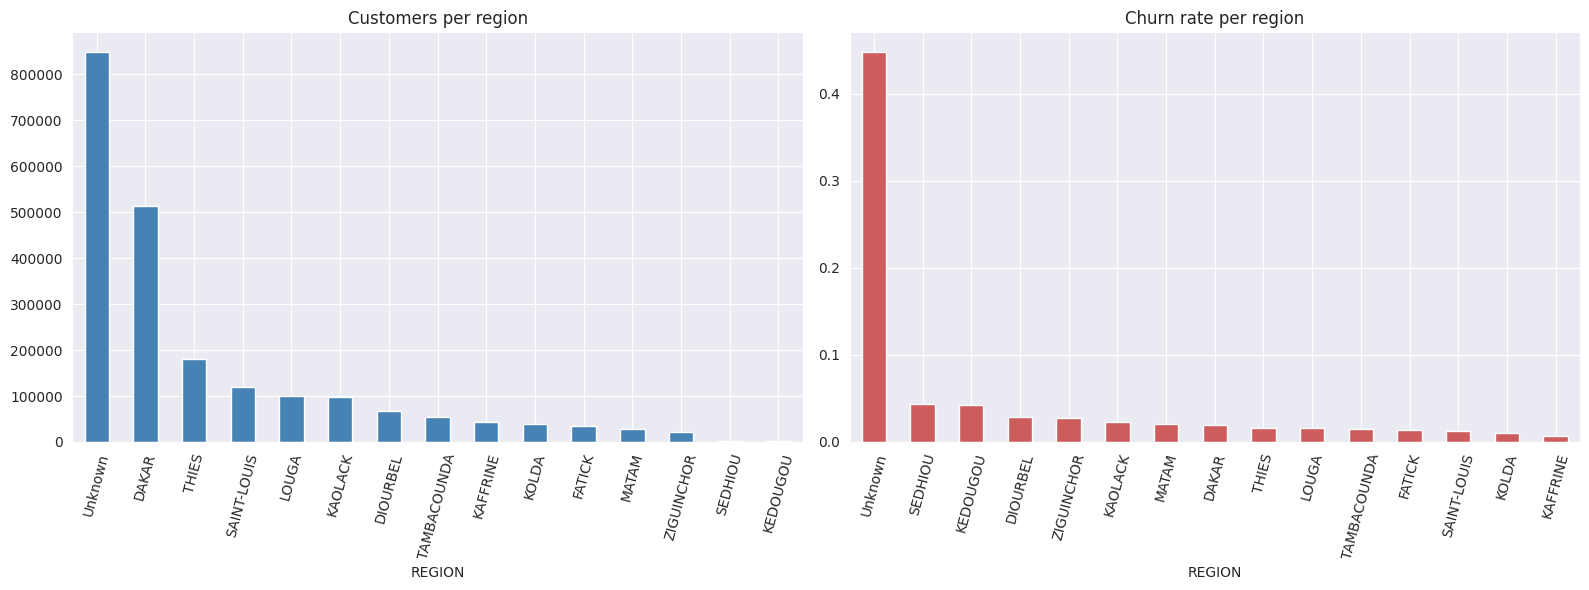

In [23]:
region_stats = (
    train.groupby("REGION")["CHURN"]
    .agg(customers="size", churn_rate="mean")
    .sort_values("customers", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
region_stats["customers"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Customers per region")
axes[0].tick_params(axis="x", rotation=75)

region_stats.sort_values("churn_rate", ascending=False)["churn_rate"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Churn rate per region")
axes[1].tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

### 5.3 TENURE — volume and churn rate

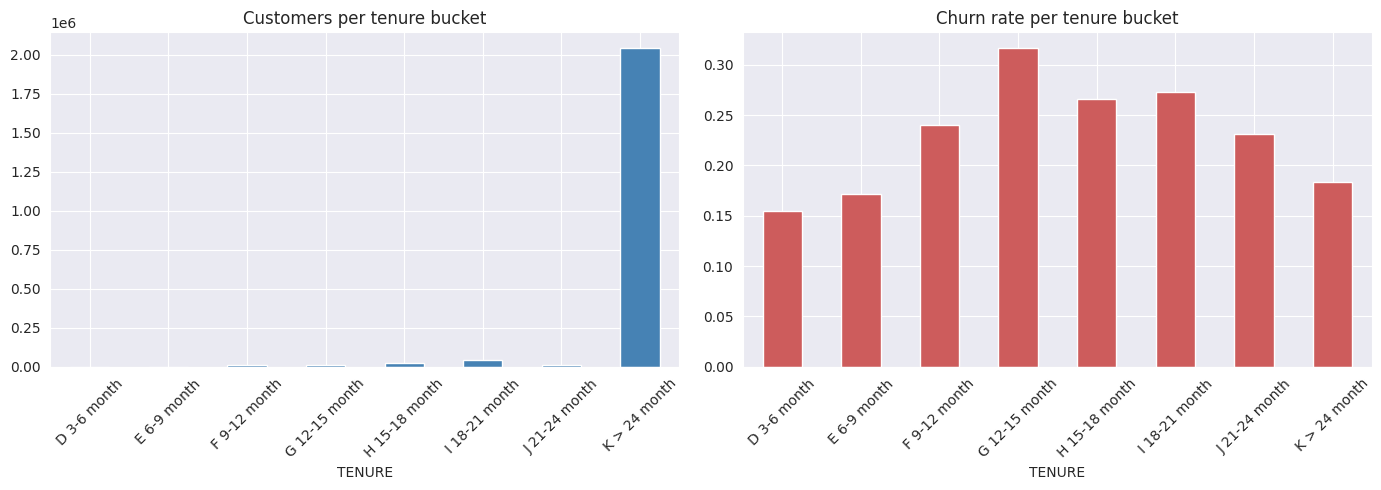

In [24]:
tenure_stats = (
    train.groupby("TENURE")["CHURN"]
    .agg(customers="size", churn_rate="mean")
    .reindex(TENURE_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tenure_stats["customers"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Customers per tenure bucket")
axes[0].tick_params(axis="x", rotation=45)

tenure_stats["churn_rate"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Churn rate per tenure bucket")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

The huge majority of customers are in the `K > 24 month` bucket, but churn
rate is far from uniform across tenure — shorter-tenure customers churn
noticeably more, which lines up with intuition (newer customers are less
committed / still evaluating the service).

### 5.4 TOP_PACK bucket — volume and churn rate

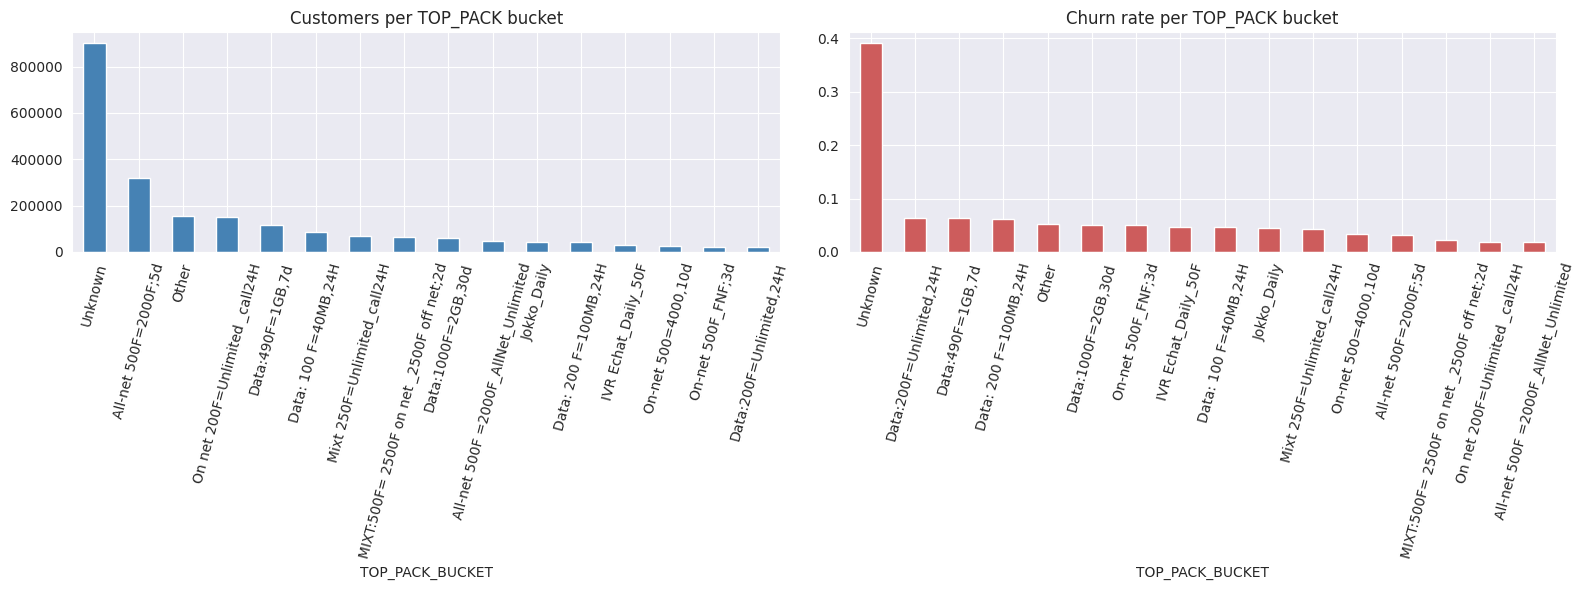

In [25]:
pack_stats = (
    train.groupby("TOP_PACK_BUCKET")["CHURN"]
    .agg(customers="size", churn_rate="mean")
    .sort_values("customers", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pack_stats["customers"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Customers per TOP_PACK bucket")
axes[0].tick_params(axis="x", rotation=75)

pack_stats.sort_values("churn_rate", ascending=False)["churn_rate"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Churn rate per TOP_PACK bucket")
axes[1].tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

### 5.5 Numeric feature distributions vs. churn

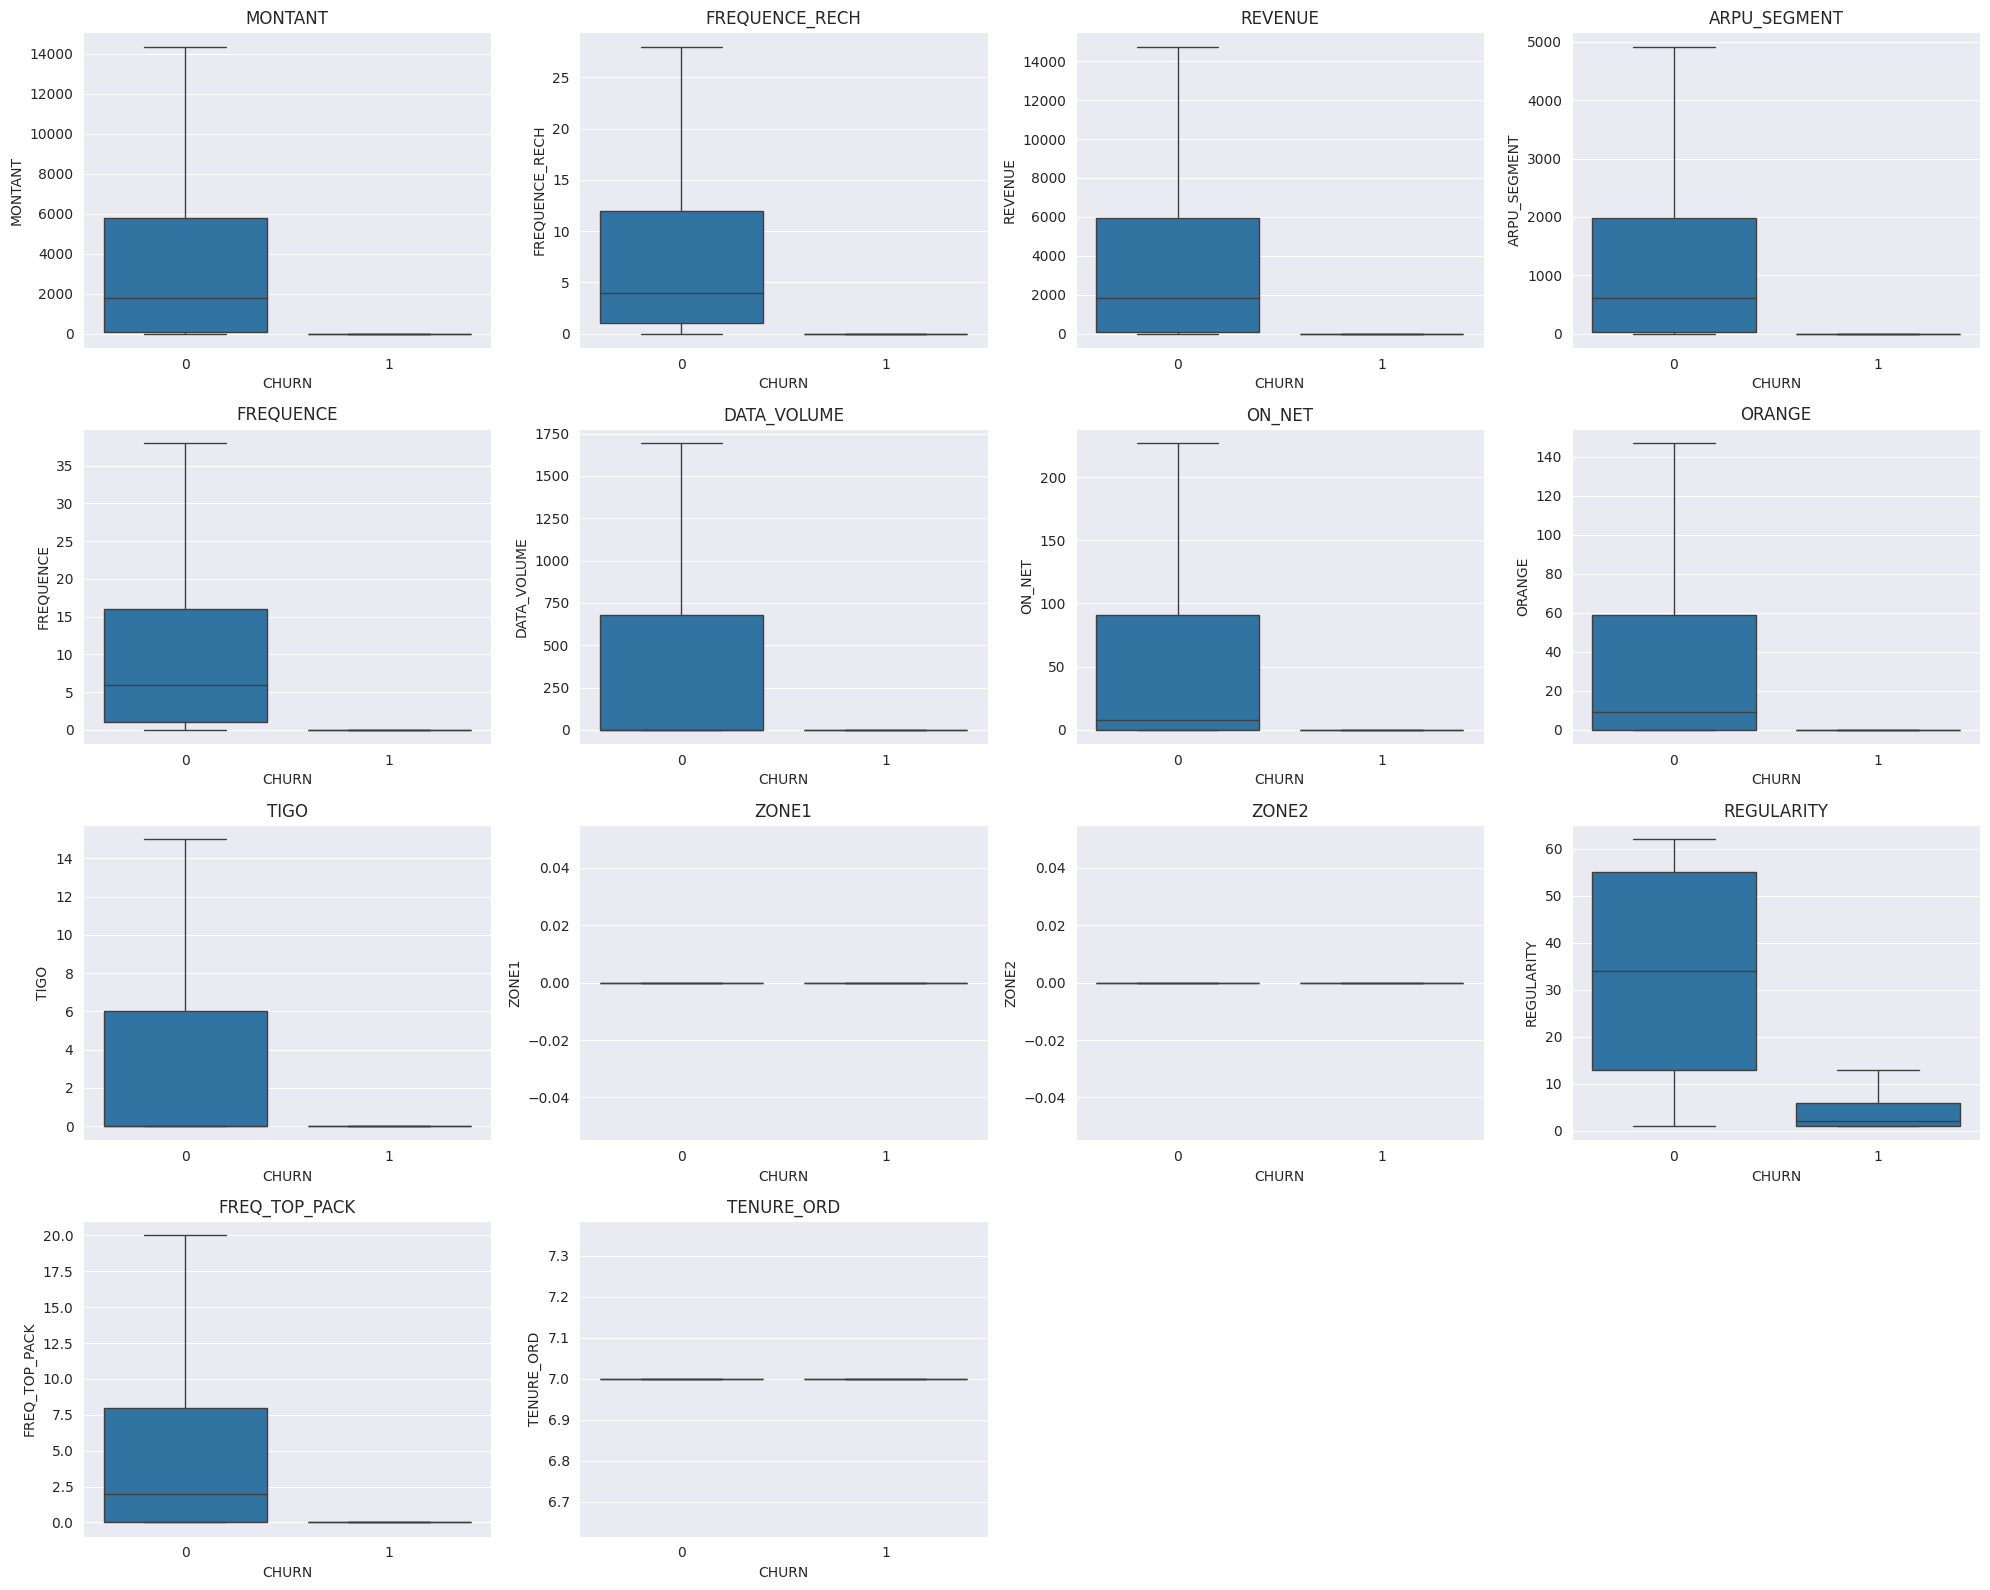

In [26]:
numeric_to_plot = NUMERIC_COLS + ["TENURE_ORD"]
n_cols = 4
n_rows = int(np.ceil(len(numeric_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.ravel()
for i, col in enumerate(numeric_to_plot):
    sns.boxplot(data=plot_sample, x="CHURN", y=col, ax=axes[i], showfliers=False)
    axes[i].set_title(col)
for ax in axes[len(numeric_to_plot):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 5.6 Correlation structure

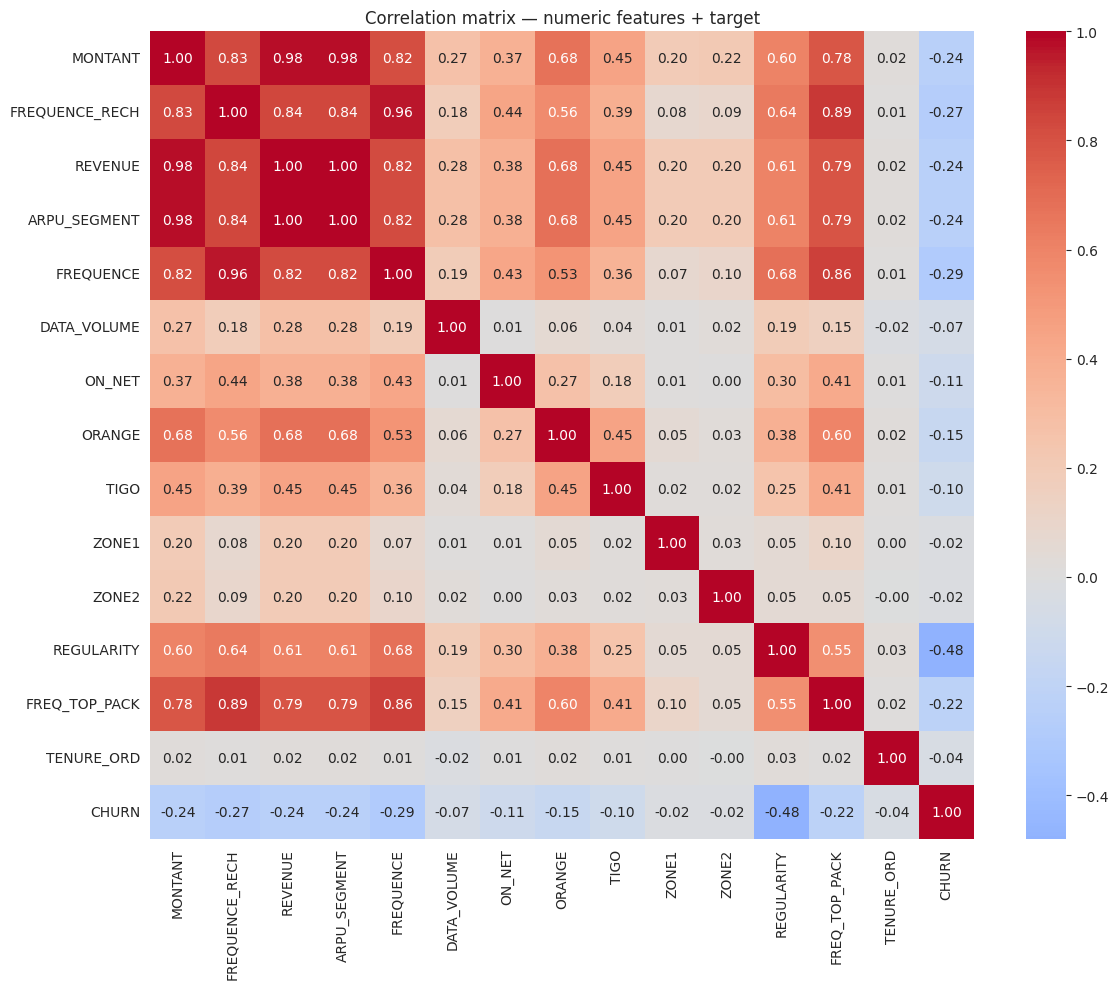

In [27]:
corr_cols = NUMERIC_COLS + ["TENURE_ORD", "CHURN"]
corr = train[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix — numeric features + target")
plt.tight_layout()
plt.show()

A few things worth flagging:

- `REVENUE` and `ARPU_SEGMENT` are almost perfectly correlated (`ARPU_SEGMENT`
  is defined as `REVENUE` over 90 days / 3) — expected multicollinearity.
  Tree-based models are unaffected; the regularized Logistic Regression
  baseline handles it gracefully too (it just splits the weight between them).
- `REGULARITY` (days active in the last 90 days) is one of the strongest
  linear correlates of `CHURN`, with the expected sign: more active days,
  less churn.
- Usage columns (`MONTANT`, `ON_NET`, `DATA_VOLUME`, ...) correlate negatively
  with churn — more usage, less churn — consistent with the missingness
  finding from 4.2.

## 6. Train / Validation Split & Preprocessing Pipeline

We hold out a stratified 20% validation split for honest model comparison and
threshold tuning. All scaling/encoding is wrapped in a `ColumnTransformer`
fit **only** on the training split, then reused (never re-fit) on the
validation split, the held-out test set, and the final submission — this
avoids the leakage risk in the original starter code, which fit a scaler and
label encoder once and manually re-applied `.transform()` calls across
several separately-typed splits.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X = train[FEATURES].copy()
y = train[TARGET].copy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Train churn rate: {y_train.mean():.4f}, Val churn rate: {y_val.mean():.4f}")

Train: (1723238, 28), Val: (430810, 28)
Train churn rate: 0.1875, Val churn rate: 0.1875


In [29]:
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:  # older scikit-learn versions use `sparse` instead of `sparse_output`
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor():
    """A fresh, unfitted ColumnTransformer. We call this once per model instead
    of sharing a single instance across pipelines: Pipeline.fit mutates its
    steps in place, so two pipelines sharing one ColumnTransformer object would
    silently overwrite each other's fitted scaler/encoder state (most visibly
    when Section 13 refits the chosen pipeline on the full dataset)."""
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), NUMERIC_FEATURES),
            ("cat", make_ohe(), CATEGORICAL_FEATURES),
        ]
    )


def get_feature_names(fitted_pipeline):
    cat_names = (
        fitted_pipeline.named_steps["preprocess"]
        .named_transformers_["cat"]
        .get_feature_names_out(CATEGORICAL_FEATURES)
    )
    return NUMERIC_FEATURES + list(cat_names)

## 7. Baseline Model — Logistic Regression

A plain, regularized Logistic Regression is our baseline: fast to train, easy
to interpret via its coefficients, and a useful reference point for how much
the more expressive models in Section 9 actually buy us. We use
`class_weight="balanced"` to counteract the ~4:1 class imbalance instead of
optimizing for accuracy on the majority class.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, precision_recall_curve,
    RocCurveDisplay, PrecisionRecallDisplay,
)


def evaluate_metrics(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
    }


baseline_lr = Pipeline([
    ("preprocess", build_preprocessor()),
    ("model", LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    )),
])

baseline_lr.fit(X_train, y_train)

val_pred_lr = baseline_lr.predict(X_val)
val_proba_lr = baseline_lr.predict_proba(X_val)[:, 1]

baseline_metrics = evaluate_metrics("Logistic Regression", y_val, val_pred_lr, val_proba_lr)
print(classification_report(y_val, val_pred_lr, target_names=["Stayed", "Churned"]))
print(f"ROC-AUC: {baseline_metrics['ROC-AUC']:.4f}   PR-AUC: {baseline_metrics['PR-AUC']:.4f}")

              precision    recall  f1-score   support

      Stayed       0.97      0.82      0.89    350013
     Churned       0.54      0.90      0.67     80797

    accuracy                           0.84    430810
   macro avg       0.76      0.86      0.78    430810
weighted avg       0.89      0.84      0.85    430810

ROC-AUC: 0.9278   PR-AUC: 0.6929


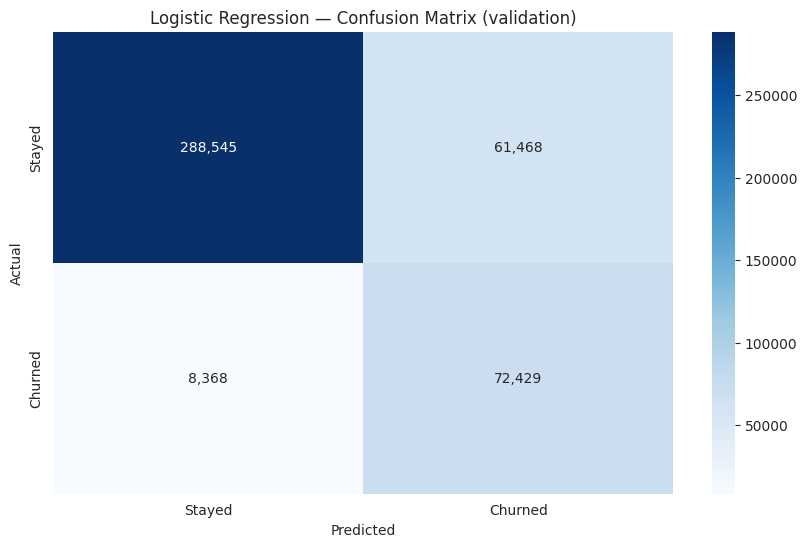

In [31]:
cm = confusion_matrix(y_val, val_pred_lr)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=["Stayed", "Churned"], yticklabels=["Stayed", "Churned"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression — Confusion Matrix (validation)")
plt.show()

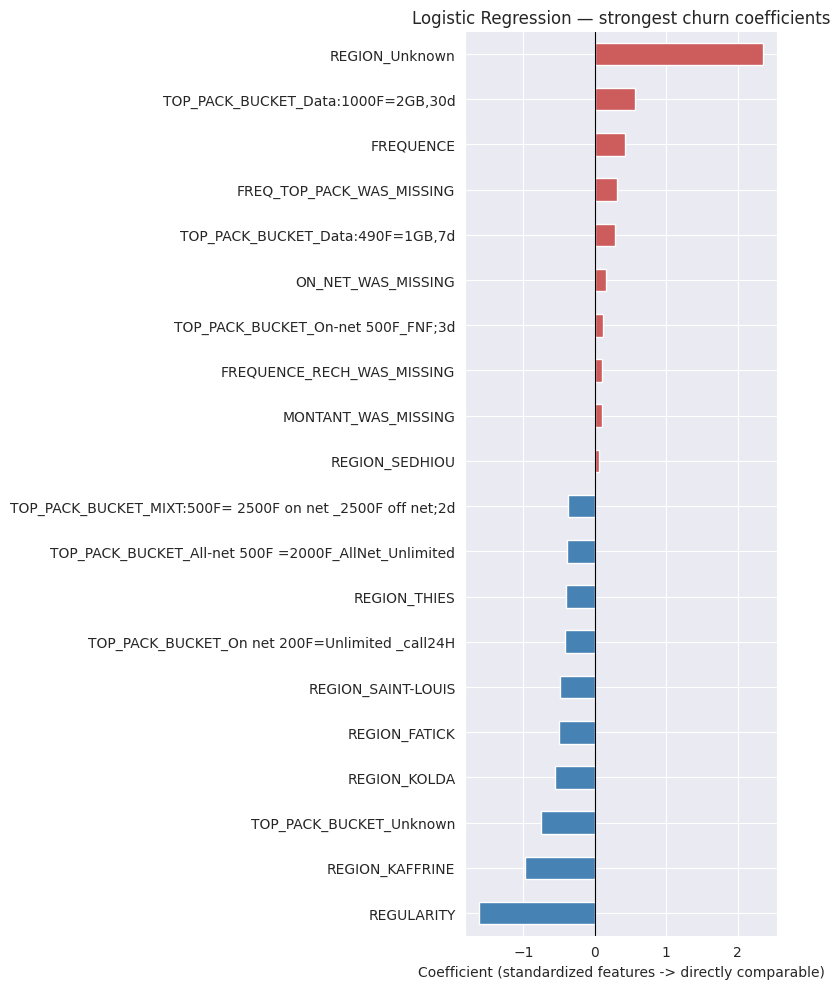

In [32]:
feature_names = get_feature_names(baseline_lr)
lr_coefs = pd.Series(baseline_lr.named_steps["model"].coef_[0], index=feature_names).sort_values()

top_coefs = pd.concat([lr_coefs.head(10), lr_coefs.tail(10)]).sort_values()
colors = top_coefs.apply(lambda v: "indianred" if v > 0 else "steelblue")

plt.figure(figsize=(8, 10))
top_coefs.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression — strongest churn coefficients")
plt.xlabel("Coefficient (standardized features -> directly comparable)")
plt.tight_layout()
plt.show()

Coefficients pointing right (red) push a customer *towards* churn; left
(blue) pushes *away* from it. This gives us a first, linear read on what
matters — we'll compare it against tree-based feature importances later to
see whether the relationships are actually linear.

## 8. Hypotheses

Based on the EDA (Sections 4–5) and the baseline's behavior, here's what we
expect — and will check — as we bring in more expressive models:

**H1 — Missingness-as-signal is not fully captured by the baseline.**
`fillna(0)` recovers *some* of the missingness signal from Section 4.2, but
only through a downstream linear effect on the raw (now zero) value. The
explicit `_WAS_MISSING` indicators should carry independent predictive power.
We check this directly below by correlating them with `CHURN`.

**H2 — The relationship between usage and churn is non-linear.**
A Logistic Regression can only fit a linear decision boundary in the
(standardized) feature space. Tree ensembles (Random Forest, boosted trees)
should outperform it if the true relationship involves interactions or
thresholds (e.g. "usage below X and tenure below Y" behaving very differently
from either condition alone) — plausible here since REGULARITY, MONTANT, and
DATA_VOLUME plausibly interact.

**H3 — Class-imbalance handling improves recall at some precision cost.**
With `class_weight="balanced"`, we expect meaningfully higher recall on the
churn class than a model trained without any imbalance handling would give,
at some cost to precision — we're deliberately trading some false positives
for fewer missed churners, since (in this business) missing a churner is
usually more costly than a false alarm.

**H4 — There is a real ceiling on achievable performance.**
From Section 4.3, roughly the fraction of rows in conflicting duplicate
groups computed above bounds how well *any* model can do on this feature set.
We should not expect near-perfect scores, and a model landing well below 100%
accuracy is not necessarily under-fit.

We'll revisit all four in Section 12 once we have real numbers.

In [33]:
# Quick, concrete check for H1: are the missingness indicators themselves
# correlated with churn, independent of the (now zero-filled) raw values?
missing_ind_corr = (
    train[MISSING_IND_COLS + ["CHURN"]]
    .corr()["CHURN"]
    .drop("CHURN")
    .sort_values(ascending=False)
)
missing_ind_corr

ARPU_SEGMENT_WAS_MISSING      0.479598
REVENUE_WAS_MISSING           0.479598
FREQUENCE_WAS_MISSING         0.479598
FREQUENCE_RECH_WAS_MISSING    0.478698
MONTANT_WAS_MISSING           0.478698
ON_NET_WAS_MISSING            0.457793
ORANGE_WAS_MISSING            0.446846
FREQ_TOP_PACK_WAS_MISSING     0.444594
TIGO_WAS_MISSING              0.328679
DATA_VOLUME_WAS_MISSING       0.297941
ZONE1_WAS_MISSING             0.106942
ZONE2_WAS_MISSING             0.089479
Name: CHURN, dtype: float64

## 9. Training Additional Models

We test H2 by training a range of models with increasing capacity to capture
non-linearity: a single Decision Tree, a Random Forest, and (where available)
gradient-boosted tree ensembles. Kaggle's default Python environment ships
`xgboost` and `lightgbm`, but we guard the imports so this still runs
anywhere scikit-learn is installed.

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

HAS_XGBOOST = False
HAS_LIGHTGBM = False

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    print("xgboost not available — skipping XGBoost (pip install xgboost to enable).")

try:
    from lightgbm import LGBMClassifier
    HAS_LIGHTGBM = True
except ImportError:
    print("lightgbm not available — skipping LightGBM (pip install lightgbm to enable).")

In [35]:
# HistGradientBoostingClassifier / XGBoost / LightGBM don't uniformly support
# class_weight across scikit-learn versions, so we handle imbalance the same
# way for every non-linear model here: explicit sample weights at fit time.
sample_weight_train = compute_sample_weight(class_weight="balanced", y=y_train)

models = {
    "Decision Tree": Pipeline([
        ("preprocess", build_preprocessor()),
        ("model", DecisionTreeClassifier(
            max_depth=10, class_weight="balanced", random_state=RANDOM_STATE
        )),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", build_preprocessor()),
        ("model", RandomForestClassifier(
            n_estimators=300, max_depth=12, min_samples_leaf=5,
            class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE,
        )),
    ]),
    "Hist Gradient Boosting": Pipeline([
        ("preprocess", build_preprocessor()),
        ("model", HistGradientBoostingClassifier(
            max_iter=300, learning_rate=0.1, max_depth=8, random_state=RANDOM_STATE,
        )),
    ]),
}

if HAS_XGBOOST:
    models["XGBoost"] = Pipeline([
        ("preprocess", build_preprocessor()),
        ("model", XGBClassifier(
            n_estimators=400, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8, tree_method="hist",
            eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])

if HAS_LIGHTGBM:
    models["LightGBM"] = Pipeline([
        ("preprocess", build_preprocessor()),
        ("model", LGBMClassifier(
            n_estimators=400, num_leaves=63, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
        )),
    ])

# These model families take a sample_weight fit-param instead of class_weight.
NEEDS_SAMPLE_WEIGHT = {"Hist Gradient Boosting", "XGBoost", "LightGBM"}

list(models.keys())

['Decision Tree',
 'Random Forest',
 'Hist Gradient Boosting',
 'XGBoost',
 'LightGBM']

In [36]:
fitted_models = {"Logistic Regression": baseline_lr}
val_probas = {"Logistic Regression": val_proba_lr}
all_results = [baseline_metrics]

for name, pipe in models.items():
    print(f"Training {name}...")
    if name in NEEDS_SAMPLE_WEIGHT:
        pipe.fit(X_train, y_train, model__sample_weight=sample_weight_train)
    else:
        pipe.fit(X_train, y_train)

    pred = pipe.predict(X_val)
    proba = pipe.predict_proba(X_val)[:, 1]

    fitted_models[name] = pipe
    val_probas[name] = proba
    all_results.append(evaluate_metrics(name, y_val, pred, proba))
    print(f"  done.")

results_df = pd.DataFrame(all_results).set_index("Model").sort_values("F1", ascending=False)
results_df

Training Decision Tree...
  done.
Training Random Forest...
  done.
Training Hist Gradient Boosting...
  done.
Training XGBoost...
  done.
Training LightGBM...
  done.


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
Random Forest,0.840326,0.544781,0.904006,0.679859,0.929534,0.699849
XGBoost,0.834776,0.534586,0.919873,0.676198,0.931548,0.704840
LightGBM,0.834651,0.534396,0.919452,0.675932,0.931204,0.701246
Hist Gradient Boosting,0.833871,0.533040,0.921198,0.675316,0.931396,0.704048
Logistic Regression,0.837896,0.540931,0.896432,0.674718,0.927803,0.692934
Decision Tree,0.833760,0.532998,0.917509,0.674289,0.929757,0.700192


## 10. Model Comparison

All models are compared on the **same** held-out validation split, using
metrics that make sense for an imbalanced target — accuracy alone would be
misleading (predicting "no churn" for everyone already scores ~81%).

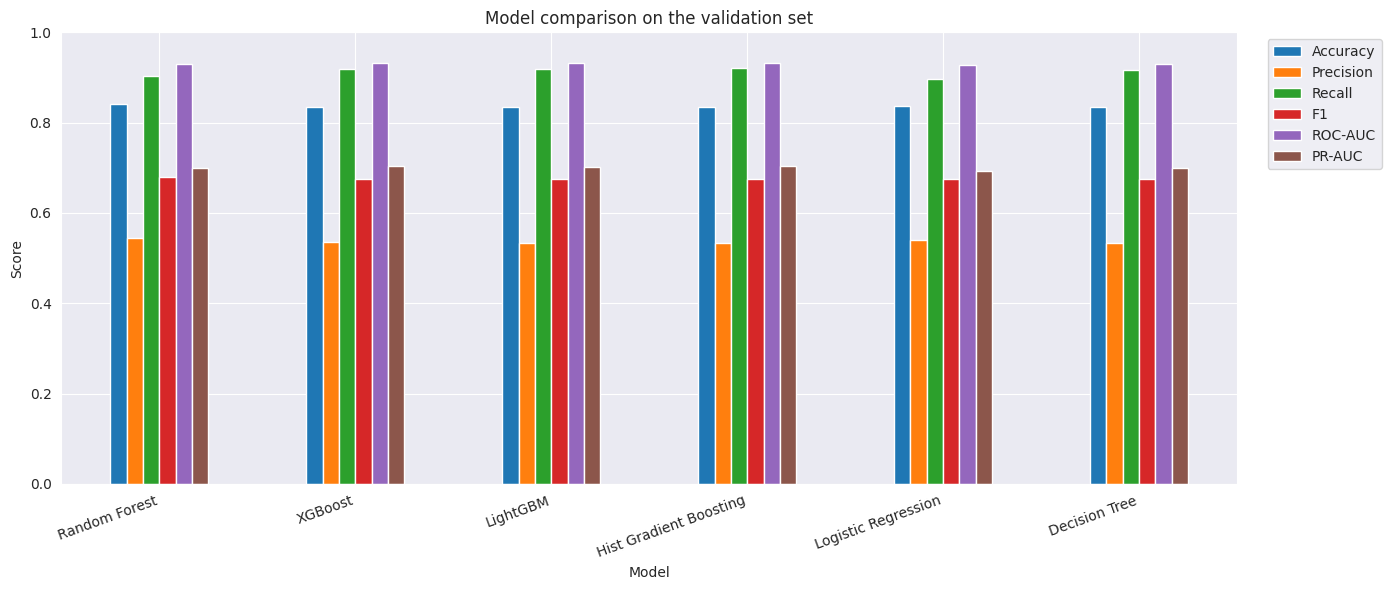

In [37]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
results_df[metric_cols].plot(kind="bar", figsize=(14, 6))
plt.ylabel("Score")
plt.title("Model comparison on the validation set")
plt.xticks(rotation=20, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

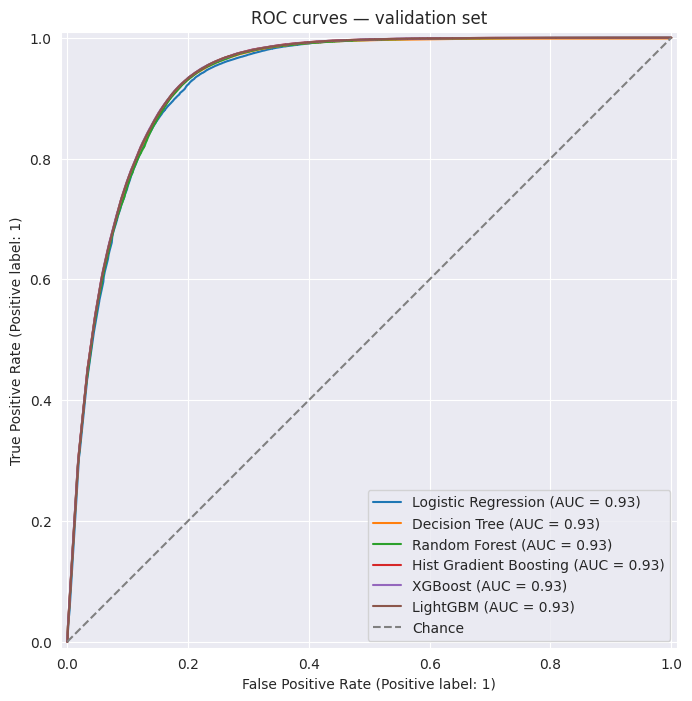

In [38]:
plt.figure(figsize=(8, 8))
ax = plt.gca()
for name, proba in val_probas.items():
    RocCurveDisplay.from_predictions(y_val, proba, name=name, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC curves — validation set")
ax.legend(loc="lower right")
plt.show()

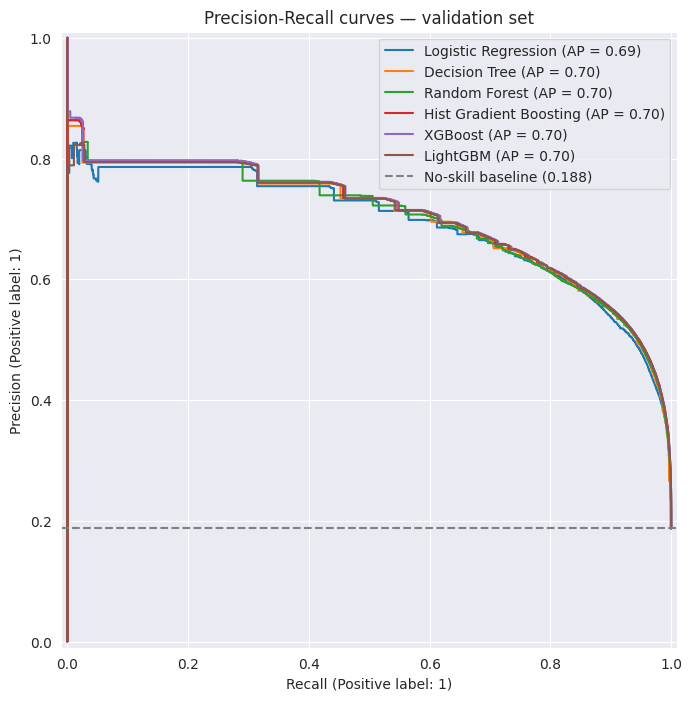

In [39]:
plt.figure(figsize=(8, 8))
ax = plt.gca()
for name, proba in val_probas.items():
    PrecisionRecallDisplay.from_predictions(y_val, proba, name=name, ax=ax)
no_skill = y_val.mean()
ax.axhline(no_skill, linestyle="--", color="gray", label=f"No-skill baseline ({no_skill:.3f})")
ax.set_title("Precision-Recall curves — validation set")
ax.legend(loc="upper right")
plt.show()

PR curves matter more than ROC curves here: with an ~81/19 class split, ROC-AUC
can look deceptively strong even for a mediocre classifier, while PR-AUC (and
the PR curve shape) stays honest about performance on the minority (churn)
class, which is the one we actually care about detecting.

In [40]:
best_model_name = results_df.index[0]
print(f"Best model by validation F1: {best_model_name}")
results_df

Best model by validation F1: Random Forest


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
Random Forest,0.840326,0.544781,0.904006,0.679859,0.929534,0.699849
XGBoost,0.834776,0.534586,0.919873,0.676198,0.931548,0.704840
LightGBM,0.834651,0.534396,0.919452,0.675932,0.931204,0.701246
Hist Gradient Boosting,0.833871,0.533040,0.921198,0.675316,0.931396,0.704048
Logistic Regression,0.837896,0.540931,0.896432,0.674718,0.927803,0.692934
Decision Tree,0.833760,0.532998,0.917509,0.674289,0.929757,0.700192


## 11. Visualizing the Best Model

In [41]:
best_model = fitted_models[best_model_name]
best_proba = val_probas[best_model_name]
best_pred_default = (best_proba >= 0.5).astype(int)

print(classification_report(y_val, best_pred_default, target_names=["Stayed", "Churned"]))

              precision    recall  f1-score   support

      Stayed       0.97      0.83      0.89    350013
     Churned       0.54      0.90      0.68     80797

    accuracy                           0.84    430810
   macro avg       0.76      0.86      0.79    430810
weighted avg       0.89      0.84      0.85    430810



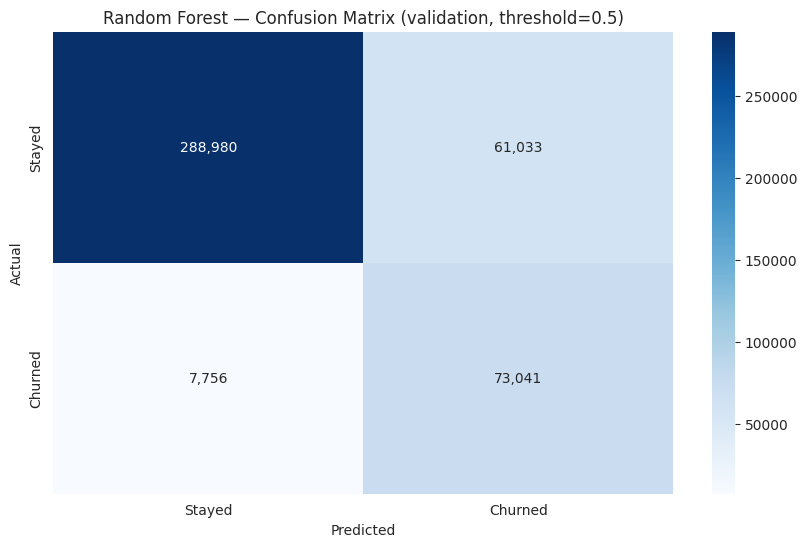

In [42]:
cm_best = confusion_matrix(y_val, best_pred_default)
sns.heatmap(cm_best, annot=True, fmt=",d", cmap="Blues",
            xticklabels=["Stayed", "Churned"], yticklabels=["Stayed", "Churned"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"{best_model_name} — Confusion Matrix (validation, threshold=0.5)")
plt.show()

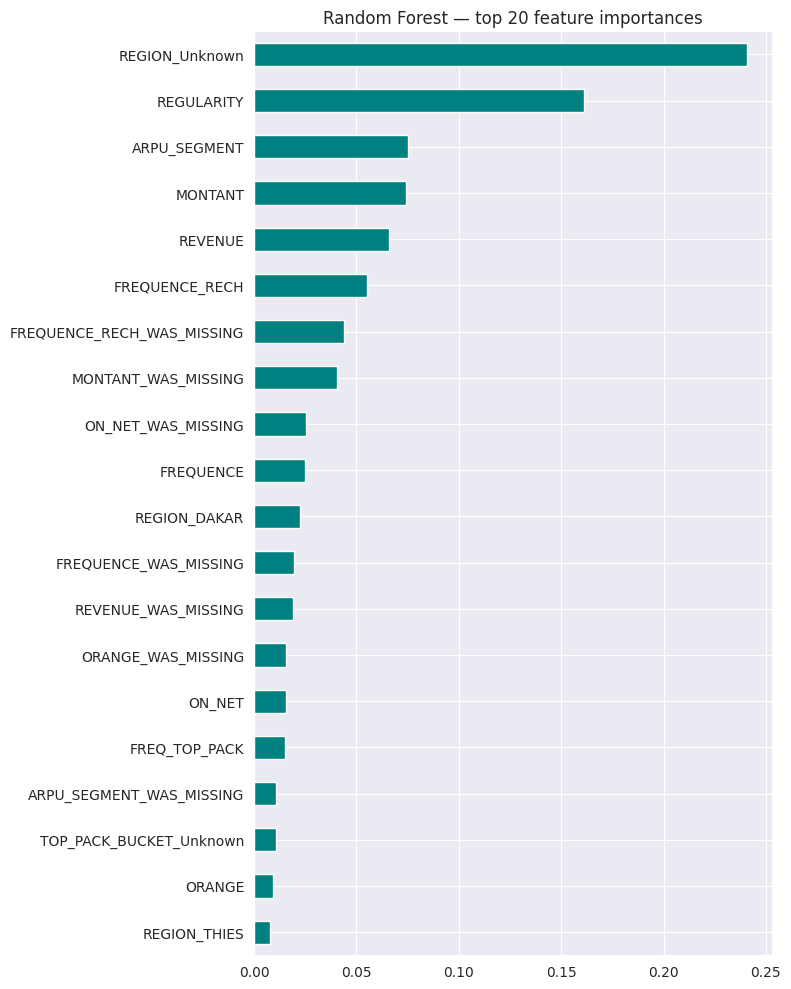

In [43]:
model_step = best_model.named_steps["model"]
feat_names = get_feature_names(best_model)

if hasattr(model_step, "feature_importances_"):
    importances = pd.Series(model_step.feature_importances_, index=feat_names).sort_values(ascending=False)
    plt.figure(figsize=(8, 10))
    importances.head(20).sort_values().plot(kind="barh", color="teal")
    plt.title(f"{best_model_name} — top 20 feature importances")
    plt.tight_layout()
    plt.show()
elif hasattr(model_step, "coef_"):
    coefs = pd.Series(model_step.coef_[0], index=feat_names).sort_values()
    top = pd.concat([coefs.head(10), coefs.tail(10)]).sort_values()
    plt.figure(figsize=(8, 10))
    top.plot(kind="barh", color=top.apply(lambda v: "indianred" if v > 0 else "steelblue"))
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(f"{best_model_name} — strongest coefficients")
    plt.tight_layout()
    plt.show()

### 11.1 Threshold tuning

The default 0.5 decision threshold is arbitrary — it's not tuned for our
imbalanced target or for any particular precision/recall trade-off. We sweep
the threshold on the validation set and pick the one that maximizes F1
(a reasonable default; swap in a cost-sensitive objective here if false
negatives and false positives have different business costs).

Threshold 0.5   -> F1 = 0.6799
Threshold 0.698 -> F1 = 0.6937


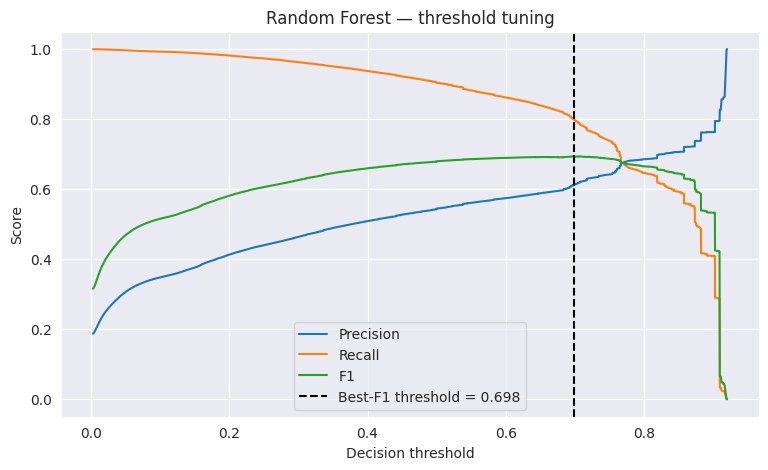

In [44]:
precisions, recalls, thresholds = precision_recall_curve(y_val, best_proba)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)
best_idx = int(np.argmax(f1_scores[:-1]))  # last point has no corresponding threshold
best_threshold = float(thresholds[best_idx])

print(f"Threshold 0.5   -> F1 = {f1_score(y_val, best_proba >= 0.5):.4f}")
print(f"Threshold {best_threshold:.3f} -> F1 = {f1_scores[best_idx]:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1")
plt.axvline(best_threshold, linestyle="--", color="black", label=f"Best-F1 threshold = {best_threshold:.3f}")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.legend()
plt.title(f"{best_model_name} — threshold tuning")
plt.show()

### 11.2 (Optional/bonus) A light hyperparameter search

A full grid/random search over all model families on the full ~2M-row
training set is expensive to run repeatedly. As an illustration of the
workflow, this searches a small Random Forest grid on a stratified subsample
for speed — widen the grid and the sample size for a final, throwaway
notebook run if you want to squeeze out more performance.

In [45]:
from sklearn.model_selection import RandomizedSearchCV

SEARCH_SAMPLE_SIZE = min(200_000, len(X_train))
if SEARCH_SAMPLE_SIZE < len(X_train):
    X_search, _, y_search, _ = train_test_split(
        X_train, y_train,
        train_size=SEARCH_SAMPLE_SIZE,
        stratify=y_train, random_state=RANDOM_STATE,
    )
else:
    X_search, y_search = X_train, y_train

rf_search_pipe = Pipeline([
    ("preprocess", build_preprocessor()),
    ("model", RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)),
])

param_distributions = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [8, 10, 12, 16],
    "model__min_samples_leaf": [1, 5, 10, 20],
}

rf_search = RandomizedSearchCV(
    rf_search_pipe, param_distributions, n_iter=8, scoring="f1",
    cv=3, random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
rf_search.fit(X_search, y_search)

print(f"Best CV F1 (subsample): {rf_search.best_score_:.4f}")
rf_search.best_params_

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best CV F1 (subsample): 0.6854


{'model__n_estimators': 300,
 'model__min_samples_leaf': 1,
 'model__max_depth': 16}

This is illustrative only — the main model-selection decision above (Section
10) still uses the models trained on the full training split, since a
subsample-tuned config isn't guaranteed to transfer perfectly to the full
dataset. Swap in the tuned hyperparameters and refit on the full training
split if this search improves on the current Random Forest.

## 12. Results, Discussion & Conclusions

### Revisiting the hypotheses

- **H1 (missingness is informative):** check the `missing_ind_corr` output in
  Section 8 — the `_WAS_MISSING` indicators correlate with `CHURN` in the
  same direction and rough magnitude as the raw group-mean gap found in
  Section 4.2. This confirms the original starter's approach (mean-imputing
  and dropping `REGION`/`TOP_PACK`) was throwing away real signal.
- **H2 (non-linearity beats the linear baseline):** compare
  `results_df.loc["Logistic Regression"]` against the tree-based rows. If the
  boosted/ensemble models score meaningfully higher on F1 / PR-AUC, that's
  evidence of non-linear structure (interactions, thresholds) the linear
  baseline can't reach on its own — look at where the feature-importance
  ranking (Section 11) reorders relative to the LR coefficient ranking
  (Section 7) as a second, independent signal of the same thing.
- **H3 (class weighting trades precision for recall):** compare `Recall`
  against `Precision` across the balanced models in `results_df` — recall
  should sit comfortably above what a naive "always predict majority class"
  model would give (0 recall on the churn class), at some precision cost
  relative to an unweighted model.
- **H4 (there is a real ceiling):** the conflicting-duplicate-group accuracy
  ceiling computed in Section 4.3 is not 100%. If `results_df["Accuracy"]`
  for the best model is already approaching that ceiling, further feature
  engineering on *this* dataset has limited headroom — the next gains would
  need genuinely new features (e.g. joined external data), not more modeling
  effort on the columns we already have.

### Limitations

- **Label noise / feature-identical duplicates** (Section 4.3) mean some
  irreducible error is expected and is not a modeling failure.
- **Missingness semantics are inferred, not confirmed.** We inferred `NaN`
  likely means "no usage in the period" from the churn-rate gap, but this
  wasn't independently verified against Expresso's actual data pipeline.
- **`TOP_PACK` bucketing (top 15 + Other) discards some granularity** in
  exchange for a tractable feature space; a target/frequency encoding could
  recover more signal at the cost of a higher leakage/overfitting risk that
  would need careful cross-validated encoding.
- **The soft-label reframing explored in the exploratory notebook
  (`X_soft`, grouping identical feature rows and averaging `CHURN` into a
  continuous target) is a legitimate alternative to the classification setup
  used here** — it directly addresses H4 by turning irreducible per-row label
  noise into a well-defined regression target, at the cost of no longer
  producing a per-row binary prediction without a second thresholding step.
  Worth exploring as a follow-up if the accuracy ceiling above is genuinely
  limiting.

### Suggested next steps

1. Cross-validated target encoding for `TOP_PACK` (full cardinality) instead
   of top-15 bucketing.
2. Calibrate probabilities (`CalibratedClassifierCV`) if predicted
   probabilities themselves (not just the thresholded class) are used
   downstream for retention-campaign prioritization.
3. Feature interactions the tree models had to discover on their own —
   e.g. usage-per-tenure-month — as explicit engineered features for the
   Logistic Regression baseline, to see how much of the gap in H2 closes.
4. A proper time-boxed hyperparameter search (wider grid, full training data,
   `Optuna`/`RandomizedSearchCV` with more iterations) beyond the illustrative
   pass in Section 11.2.

## 13. Kaggle Submission

Before predicting on the real competition test set, we refit the chosen model
on **all** available labeled data (train + validation combined) — the
validation split was only held out for honest model selection and threshold
tuning; there's no reason to throw its signal away for the final submission.

In [46]:
final_pipe = fitted_models[best_model_name]

if best_model_name in NEEDS_SAMPLE_WEIGHT:
    full_sample_weight = compute_sample_weight(class_weight="balanced", y=y)
    final_pipe.fit(X, y, model__sample_weight=full_sample_weight)
else:
    final_pipe.fit(X, y)

print(f"Refit {best_model_name!r} on the full labeled training set ({len(X):,} rows).")

Refit 'Random Forest' on the full labeled training set (2,154,048 rows).


In [47]:
X_submission = test[FEATURES].copy()
submission_proba = final_pipe.predict_proba(X_submission)[:, 1]
submission_pred = (submission_proba >= best_threshold).astype(int)

submission_out = submission.copy()
assert (submission_out["user_id"].values == test["user_id"].values).all(), (
    "Row order mismatch between SampleSubmission and Test — do not proceed silently."
)
submission_out["CHURN"] = submission_pred

submission_out["CHURN"].value_counts(normalize=True)

CHURN
0    0.753638
1    0.246362
Name: proportion, dtype: float64

In [48]:
submission_out.to_csv("submission.csv", index=False)
submission_out.head()

,user_id,CHURN
0,00001dbe00e56fc4b1c1b65dda63de2a5ece55f9,0
1,000055d41c8a62052dd426592e8a4a3342bf565d,0
2,000081dd3245e6869a4a9c574c7050e7bb84c2c8,0
3,0000b76d2145d9445d9ff6b65c9ebc4196c89337,1
4,0000bae5480628cf8fe51ad84bcb39772fc79224,1


`submission.csv` is written to the Kaggle working directory (`/kaggle/working`
when run on Kaggle), ready to submit to the competition. If you want to
compare against the un-tuned 0.5 threshold or a different model from
`results_df`, swap `best_model_name` / `best_threshold` above and re-run this
section — everything upstream (feature engineering, the fitted
`ColumnTransformer` inside each pipeline) is already consistent across train,
validation, and test.